# Structure–Activity Modeling of TLR4 Bioactivity Using ChEMBL Data

This notebook analyzes bioassay data related to Toll-like receptor 4 (TLR4) retrieved from the ChEMBL database.  
The objective is to curate assay-based activity data, generate molecular representations and prepare the dataset for interpretable machine learning modeling of TLR4 bioactivity.



## 1. Computational Environment Setup



In [ ]:
!pip install chembl-webresource-client



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt



## 2. Accessing the ChEMBL Database

ChEMBL is a curated database of bioactive molecules linked to biological targets
through experimentally determined assay data. The ChEMBL web resource client is
used to programmatically retrieve target and bioactivity information for TLR4.




In [ ]:
from chembl_webresource_client.new_client import new_client



## 3. Identification of the TLR4 Target

Target records were filtered to retain the human single-protein entry for Toll-like receptor 4.

### 3.1 Target Search


In [ ]:
target = new_client.target
targets = target.search("TLR4")

len(targets)


10

In [ ]:
targets_df = pd.DataFrame(targets)
targets_df[['target_chembl_id', 'organism', 'pref_name', 'target_type']]


,target_chembl_id,organism,pref_name,target_type
0,CHEMBL4106126,Homo sapiens,TLR4-MD2,PROTEIN-PROTEIN INTERACTION
1,CHEMBL5483003,Mus musculus,TLR4-MyD88,PROTEIN-PROTEIN INTERACTION
2,CHEMBL5255,Homo sapiens,Toll-like receptor 4,SINGLE PROTEIN
3,CHEMBL1795167,Mus musculus,Toll-like receptor 4,SINGLE PROTEIN
4,CHEMBL4523480,Rattus norvegicus,Toll-like receptor 4,SINGLE PROTEIN
5,CHEMBL3038512,Homo sapiens,Toll-like receptor 4/MD-2,PROTEIN COMPLEX
6,CHEMBL4296082,Mus musculus,Toll-like receptor 4/Ly96,PROTEIN COMPLEX
7,CHEMBL3038514,Mus musculus,Toll-like receptor 4/MD-2/CD14,PROTEIN COMPLEX
8,CHEMBL6067402,Homo sapiens,Protein canopy homolog 3,SINGLE PROTEIN
9,CHEMBL3038513,Homo sapiens,Toll-like receptor 4/MD-2/CD14,PROTEIN COMPLEX


### 3.2 Filtering for Human Single-Protein TLR4

Target records are filtered to retain the human single-protein entry for
Toll-like receptor 4 (Homo sapiens, SINGLE PROTEIN).

In [ ]:
human_single = targets_df[
    (targets_df['organism'] == "Homo sapiens") &
    (targets_df['target_type'] == "SINGLE PROTEIN") &
    (targets_df['pref_name'] == "Toll-like receptor 4")
]

human_single



,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
2,[],Homo sapiens,Toll-like receptor 4,16.0,False,CHEMBL5255,"[{'accession': 'O00206', 'component_descriptio...",SINGLE PROTEIN,9606


In [ ]:
tlr4_chembl_id = human_single.iloc[0]['target_chembl_id']
tlr4_chembl_id


'CHEMBL5255'

## 4. Retrieval of TLR4 Assays

Assay records associated with human TLR4 are retrieved using the ChEMBL target identifier.
These represent experimental systems in which TLR4 ligand binding or functional modulation
was evaluated.




In [ ]:
assay = new_client.assay
assays = assay.filter(target_chembl_id=tlr4_chembl_id)

len(assays)


219

## 5. Inspection of Retrieved Assays

Assay formats, experimental endpoints, and confidence scores are examined to ensure
only biologically meaningful data are retained for downstream modeling.



In [ ]:
assays_df = pd.DataFrame(assays)
assays_df[['assay_chembl_id', 'assay_type', 'description', 'confidence_score']].head()


,assay_chembl_id,assay_type,description,confidence_score
0,CHEMBL854334,F,Antagonistic potency at human TLR4 expressed i...,9
1,CHEMBL867199,F,Inhibition of induction of NF-kappaB by LPS in...,9
2,CHEMBL939463,F,Antagonist activity at TLR4 in human PBMC asse...,9
3,CHEMBL939464,F,Agonist activity at TLR4 in human PBMC assesse...,9
4,CHEMBL990601,F,Antagonist activity at human TLR4 expressed in...,9


In [ ]:
assays_df['assay_type'].value_counts()


,count
assay_type,
B,207
F,10
A,2


## 6. Filtering for Functional Assays

Assays are restricted to functional formats (assay_type = "F"), which measure downstream
cellular responses such as cytokine production or reporter gene activation.


In [ ]:
functional_assays_df = assays_df[assays_df['assay_type'] == 'F']

len(functional_assays_df)

functional_assays_df[['assay_chembl_id', 'assay_type', 'description', 'confidence_score']].head()





,assay_chembl_id,assay_type,description,confidence_score
0,CHEMBL854334,F,Antagonistic potency at human TLR4 expressed i...,9
1,CHEMBL867199,F,Inhibition of induction of NF-kappaB by LPS in...,9
2,CHEMBL939463,F,Antagonist activity at TLR4 in human PBMC asse...,9
3,CHEMBL939464,F,Agonist activity at TLR4 in human PBMC assesse...,9
4,CHEMBL990601,F,Antagonist activity at human TLR4 expressed in...,9


## 7. Retrieval of Quantitative Bioactivity Data

Bioactivity data are retrieved using concentration-based endpoints: IC50, EC50, Ki,
and Potency. Data are curated by removing missing values, restricting to nanomolar
units, and retaining entries with valid pChEMBL values. The dataset consists primarily
of IC50 and EC50 measurements.



In [ ]:
activity = new_client.activity

# Retrieve quantitative bioactivity data for TLR4
activities = activity.filter(
    target_chembl_id=tlr4_chembl_id,
    standard_type__in=['IC50', 'EC50', 'Ki', 'Potency']
)

df_activities = pd.DataFrame.from_records(activities)



In [ ]:
df_activities = df_activities[
    df_activities['standard_value'].notna()
]


In [ ]:
df_activities = df_activities[
    df_activities['standard_units'] == 'nM'
]


In [ ]:
df_activities = df_activities[
    df_activities['pchembl_value'].notna()
]

In [ ]:
df_activities = df_activities.reset_index(drop=True)


In [ ]:
# Convert activity columns to numeric
df_activities['standard_value'] = pd.to_numeric(
    df_activities['standard_value'], errors='coerce'
)

df_activities['pchembl_value'] = pd.to_numeric(
    df_activities['pchembl_value'], errors='coerce'
)


In [ ]:
print("Final dataset size:", df_activities.shape)
print("\nActivity type distribution:")
print(df_activities['standard_type'].value_counts())

print("\nSummary statistics:")
print(df_activities[['standard_value', 'pchembl_value']].describe())

Final dataset size: (256, 46)

Activity type distribution:
standard_type
IC50    138
EC50    118
Name: count, dtype: int64

Summary statistics:
       standard_value  pchembl_value
count      256.000000     256.000000
mean      6359.595945       6.333164
std      11828.551046       1.586366
min          0.010000       4.190000
25%         50.352500       5.247500
50%       1817.500000       5.740000
75%       5650.000000       7.302500
max      64100.000000      11.000000


## 8. Bioactivity Data Curation and Molecule-Level Aggregation



### 8.1 Selection of Modeling Relevant Fields


In [ ]:
selected_cols = [
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_type',
    'pchembl_value'
]

df_model = df_activities[selected_cols].copy()

df_model.head()


,molecule_chembl_id,canonical_smiles,standard_type,pchembl_value
0,CHEMBL382272,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,IC50,6.46
1,CHEMBL382272,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@@H](CCCCCCC)OC...,IC50,6.46
2,CHEMBL200140,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@@H](CCCCCCC)O...,IC50,6.60
3,CHEMBL200667,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@H](CCCCCCC)OC...,IC50,7.10
4,CHEMBL200398,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@H](CCCCCCC)OC(...,IC50,6.80


### 8.2 Molecule Level Aggregation


In [ ]:
df_model_agg = (
    df_model
    .groupby(
        ['molecule_chembl_id', 'canonical_smiles', 'standard_type'],
        as_index=False
    )
    .agg({
        'pchembl_value': 'median'
    })
)

print("After aggregation:", df_model_agg.shape)
df_model_agg.head()



After aggregation: (190, 4)


,molecule_chembl_id,canonical_smiles,standard_type,pchembl_value
0,CHEMBL1223751,CCOc1ccc(OCC(O)CN(C)Cc2c(C)nn(Cc3ccccc3Cl)c2C)cc1,IC50,4.47
1,CHEMBL200140,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@@H](CCCCCCC)O...,IC50,6.60
2,CHEMBL200398,CCCCCCCCCCCCCC(=O)N[C@H](COCC[C@H](CCCCCCC)OC(...,IC50,6.80
3,CHEMBL200667,CCCCCCCCCCCCCC(=O)N[C@@H](COCC[C@H](CCCCCCC)OC...,IC50,7.10
4,CHEMBL2046559,COc1ccc(/C=C/C(=O)O[C@H]2CC[C@@]3(C)C(=CC[C@]4...,EC50,5.40


### 8.3 Post Aggregation Summary Statistics


In [ ]:
df_model_agg['standard_type'].value_counts()
df_model_agg['pchembl_value'].describe()


,pchembl_value
count,190.000000
mean,5.779184
std,1.175238
min,4.190000
25%,5.107500
50%,5.510000
75%,6.085000
max,10.385000


## 9. Exploratory Analysis of Curated Bioactivity Data




### 9.1 Distribution of pChEMBL Values

Histograms generated per pharmacological endpoint to examine potency variability
and ensure adequate spread for regression modeling. Descriptive statistics summarize
central tendency and dispersion.


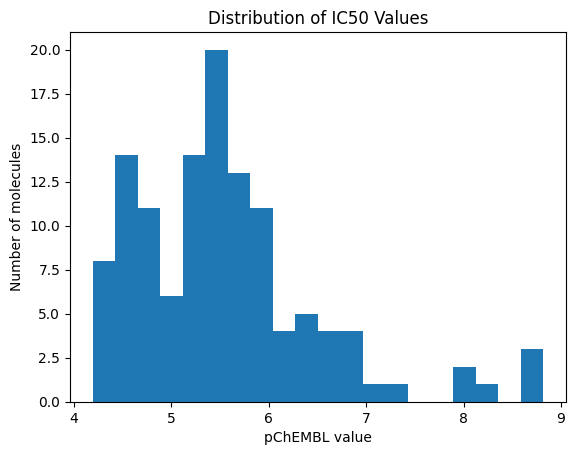

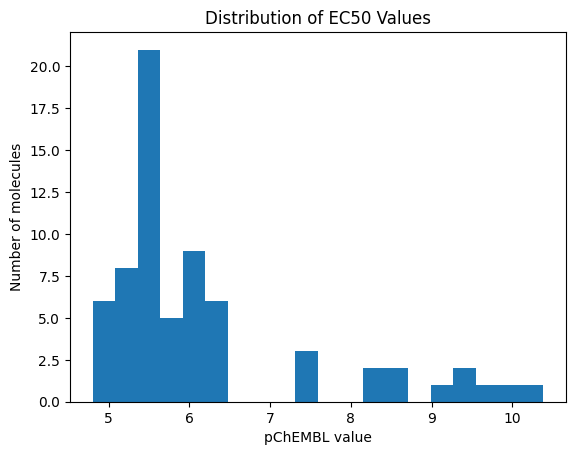

In [ ]:
import matplotlib.pyplot as plt

for endpoint in df_model_agg['standard_type'].unique():
    subset = df_model_agg[df_model_agg['standard_type'] == endpoint]

    plt.hist(subset['pchembl_value'], bins=20)
    plt.xlabel('pChEMBL value')
    plt.ylabel('Number of molecules')
    plt.title(f'Distribution of {endpoint} Values')
    plt.show()


In [ ]:
df_model_agg.groupby('standard_type')['pchembl_value'].describe()


,count,mean,std,min,25%,50%,75%,max
standard_type,,,,,,,,
EC50,68.0,6.192574,1.399224,4.80,5.4100,5.600,6.200,10.385
IC50,122.0,5.548770,0.961110,4.19,4.8225,5.415,5.935,8.820


### 9.2 Binary Activity Classification

A pChEMBL threshold of >= 6 (approximately 1 uM potency) is applied to define
active vs. inactive compounds for optional classification modeling.

In [ ]:
df_model_agg['activity_label'] = df_model_agg['pchembl_value'].apply(
    lambda x: 'active' if x >= 6 else 'inactive'
)

df_model_agg['activity_label'].value_counts()



,count
activity_label,
inactive,138
active,52


## 10. Molecular Fingerprint Generation (ECFP4)

Extended-Connectivity Fingerprints (ECFP4 / Morgan radius=2, 2048 bits) are generated
from canonical SMILES strings. These encode circular substructural information and are
widely used in QSAR modeling.





###10.1 RDKit Installation (Development Environment Only)

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 44.0 MB/s eta 0:00:00


### 10.2 Fingerprint Generator Initialization

In [ ]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

# Initialize Morgan fingerprint generator (ECFP4)
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)


### 10.3 SMILES → ECFP Conversion Function

In [ ]:
def smiles_to_ecfp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(2048, dtype=int)

    fp = morgan_gen.GetFingerprint(mol)
    return np.array(fp)


### 10.4 Fingerprint Generation for Regression Modeling

Morgan fingerprints are generated for each molecule. The resulting binary vectors
constitute the feature matrix (X); continuous pChEMBL values serve as the
regression target (y). Invalid SMILES entries are excluded.

In [ ]:
# Generate fingerprints
df_model_agg['fingerprint'] = df_model_agg['canonical_smiles'].apply(smiles_to_ecfp)

# Remove entries with invalid fingerprints (if any)
df_ml = df_model_agg.dropna(subset=['fingerprint']).copy()

# Feature matrix (X)
X = np.stack(df_ml['fingerprint'].values)

# Continuous regression target (y)
y = df_ml['pchembl_value'].values

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (190, 2048)
Target vector shape: (190,)


In [ ]:
# Inspect first fingerprint
X[0][:20]

# Check target distribution
y[:10]


array([4.47, 6.6 , 6.8 , 7.1 , 5.4 , 6.96, 6.8 , 6.17, 7.28, 5.08])

## 11. Baseline Regression Model Development

A Random Forest regressor is trained to predict continuous pChEMBL values from ECFP4
fingerprints. Random Forest was selected as a robust, non-parametric baseline capable
of capturing nonlinear structure-activity relationships without feature scaling.

Model performance is evaluated using:
- Coefficient of determination (R-squared)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)

### 11.1 Train–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (152, 2048)
Test set: (38, 2048)


### 11.2 Train Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

### 11.3 Model Evaluation

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Predictions
y_pred = rf_model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")


R²: 0.727
RMSE: 0.466
MAE: 0.308


### 11.4 Predicted vs Observed Plot

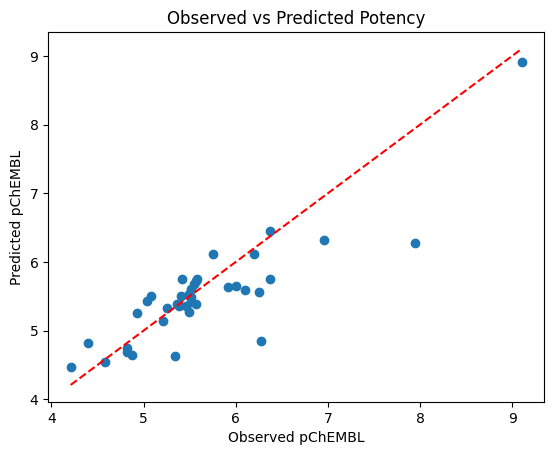

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Observed pChEMBL")
plt.ylabel("Predicted pChEMBL")
plt.title("Observed vs Predicted Potency")

plt.show()

## 12. Feature Importance Analysis

Feature importance scores are extracted from the trained Random Forest model.
Because Morgan fingerprints are hashed bit vectors, each feature encodes the
presence or absence of a specific circular substructure and not a named descriptor.
The most influential bits identify structural fragments associated with TLR4 potency.

### 12.1 Extract Feature Importance Scores

In [ ]:
import pandas as pd
import numpy as np

feature_importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'bit_index': range(X.shape[1]),
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)

importance_df.head(15)


,bit_index,importance
976,976,0.202077
125,125,0.183845
1283,1283,0.146312
650,650,0.088149
525,525,0.039760
823,823,0.036638
1290,1290,0.021835
1819,1819,0.017772
590,590,0.017747
1257,1257,0.016477


### 12.2 Visualization of Top Fingerprint Bits

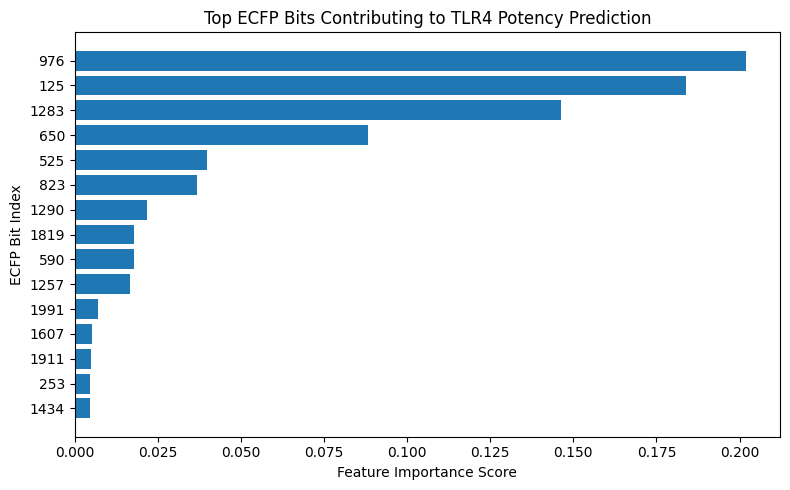

In [ ]:
import matplotlib.pyplot as plt

top_n = 15

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df['bit_index'][:top_n][::-1].astype(str),
    importance_df['importance'][:top_n][::-1]
)

plt.xlabel("Feature Importance Score")
plt.ylabel("ECFP Bit Index")
plt.title("Top ECFP Bits Contributing to TLR4 Potency Prediction")
plt.tight_layout()
plt.show()


## 13. Model Robustness — 5 Fold Cross Validation

A single train-test split depends on one random partition. Five-fold cross-validation
trains and evaluates the model five times on different data subsets, providing:

- A distribution of performance scores
- Reduced variance compared to a single split
- A more reliable estimate of generalizability

Performance is reported as mean and standard deviation of R-squared and RMSE across folds.

### 13.1 Five Fold Cross Validation

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Define 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validated R²
cv_r2 = cross_val_score(
    rf_model,
    X,
    y,
    cv=kf,
    scoring='r2'
)

# Cross-validated RMSE
cv_rmse = cross_val_score(
    rf_model,
    X,
    y,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

print("Cross-validation R² scores:", cv_r2)
print("Mean CV R²:", cv_r2.mean())

print("\nCross-validation RMSE scores:", -cv_rmse)
print("Mean CV RMSE:", -cv_rmse.mean())

Cross-validation R² scores: [0.72456775 0.64606643 0.66525496 0.84489578 0.75177293]
Mean CV R²: 0.7265115706293941

Cross-validation RMSE scores: [0.46825468 0.58893602 0.61534772 0.58440734 0.63648298]
Mean CV RMSE: 0.5786857477210156


In [ ]:
print("\nR² standard deviation:", cv_r2.std())
print("RMSE standard deviation:", (-cv_rmse).std())


R² standard deviation: 0.07054151724445758
RMSE standard deviation: 0.058339429937864236


## 14. Model Interpretability — SHAP Analysis

SHAP (SHapley Additive exPlanations) values quantify the contribution of each
ECFP fingerprint bit to individual predictions — explaining how each feature
shifts the predicted pChEMBL value relative to the model's baseline output.
A subset of the training data is used for computational efficiency.

### 14.1 Install SHAP

In [ ]:
!pip install shap


### 14.2 Compute SHAP Values

In [ ]:
import shap
import numpy as np

# Use subset to reduce computational load
X_sample = X_train[:200]

# Create SHAP explainer (tree-based model)
explainer = shap.Explainer(rf_model, X_train)

# Compute SHAP values
shap_values = explainer(X_sample)



### 14.3 Global Feature Importance (SHAP)

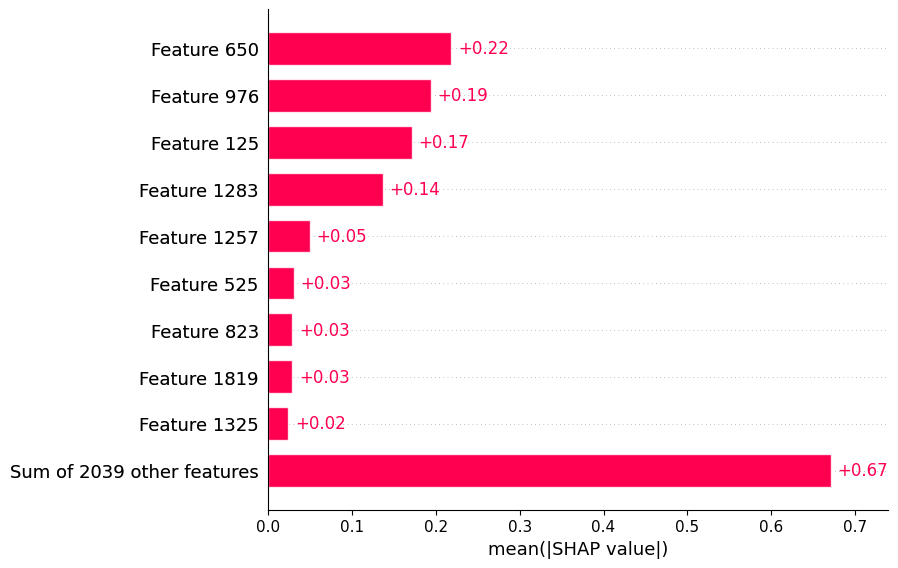

In [ ]:
shap.plots.bar(shap_values)

### 14.4 SHAP Summary Plot

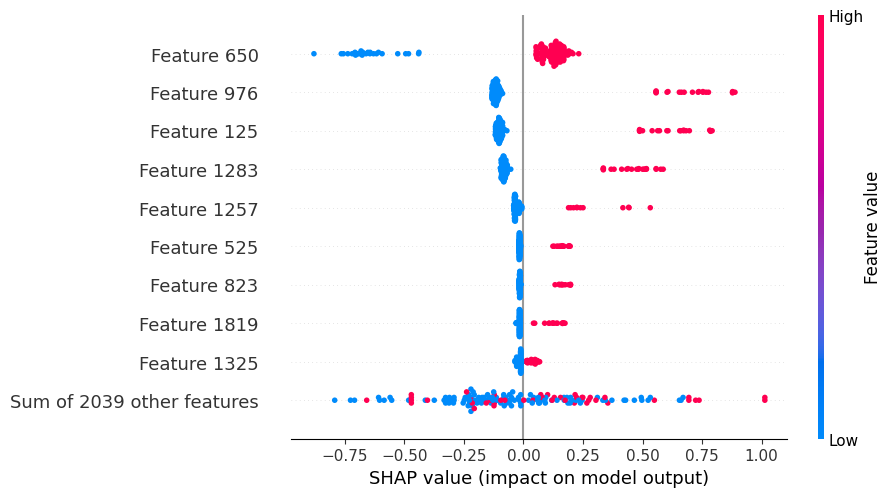

In [ ]:
shap.plots.beeswarm(shap_values)

## 15. Mapping Fingerprint Bits to Chemical Substructures

Morgan fingerprints are regenerated with bit-level information (bitInfo). The most
influential bits from SHAP analysis are mapped back to their atomic environments
and visualized using RDKit, enabling fragment-level chemical interpretation of the
structure-activity relationships learned by the model.

### 15.1 Regenerate Fingerprints with Bit Information

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import pandas as pd

def smiles_to_ecfp_with_info(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None

    bitInfo = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=radius,
        nBits=nBits,
        bitInfo=bitInfo
    )

    arr = np.zeros((nBits,))
    AllChem.DataStructs.ConvertToNumpyArray(fp, arr)

    return arr, bitInfo


In [ ]:
import warnings
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore')

df_model_agg[['fingerprint_with_info', 'bitInfo']] = (
    df_model_agg['canonical_smiles']
    .apply(lambda x: pd.Series(smiles_to_ecfp_with_info(x)))
)

df_ml = df_model_agg.dropna(subset=['fingerprint_with_info']).copy()

X = np.stack(df_ml['fingerprint_with_info'].values)
y = df_ml['pchembl_value'].values


### 15.2 Identify Most Influential Bits from SHAP

In [ ]:
# Check SHAP value shape (optional, for sanity check)
print(shap_values.values.shape)

# Mean absolute SHAP value per feature
mean_shap = np.abs(shap_values.values).mean(axis=0)

# Top 10 important bits
top_bits = np.argsort(mean_shap)[-10:][::-1]

top_bits


(152, 2048)


array([ 650,  976,  125, 1283, 1257,  525,  823, 1819, 1325, 1911])

### 15.3 Visualize a Representative Substructure

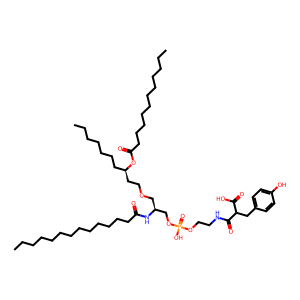

In [ ]:
from rdkit.Chem import Draw

bit_to_visualize = top_bits[0]

# Find first molecule containing this bit
for idx, row in df_ml.iterrows():
    if bit_to_visualize in row['bitInfo']:
        mol = Chem.MolFromSmiles(row['canonical_smiles'])
        atom_id, radius = row['bitInfo'][bit_to_visualize][0]
        break

# Identify atomic environment
env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_id)

atoms = set()
for bond_id in env:
    bond = mol.GetBondWithIdx(bond_id)
    atoms.add(bond.GetBeginAtomIdx())
    atoms.add(bond.GetEndAtomIdx())

Draw.MolToImage(mol, highlightAtoms=list(atoms))

## 16. Biological Interpretation of Model Findings

SHAP analysis reveals that the most influential fingerprint bits correspond to
hydrophobic and aromatic structural features — chemically plausible determinants
of TLR4 activity. This is consistent with TLR4's biological role in recognizing
lipopolysaccharide (LPS), a lipid-rich pattern from Gram-negative bacteria, where
hydrophobic contacts dominate the MD-2 binding interface.

The model appears to capture meaningful structure-activity relationships rather
than acting as a black-box predictor, supporting its use for hypothesis generation
in TLR4-targeted drug discovery.


In [ ]:
import numpy as np
import pandas as pd

# Mean absolute SHAP value per feature (regression)
mean_shap = np.abs(shap_values.values).mean(axis=0)

# Top 15 most influential fingerprint bits
top_indices = np.argsort(mean_shap)[-15:][::-1]

importance_df = pd.DataFrame({
    "Fingerprint_Bit": top_indices,
    "Mean_Absolute_SHAP": mean_shap[top_indices]
})

importance_df

,Fingerprint_Bit,Mean_Absolute_SHAP
0,650,0.218344
1,976,0.193923
2,125,0.171305
3,1283,0.136791
4,1257,0.049604
5,525,0.029885
6,823,0.028483
7,1819,0.028318
8,1325,0.023665
9,1911,0.017795


## 17. Quick Physicochemical Check

A basic drug-likeness profile is computed for all curated compounds using RDKit,
covering molecular weight (MW), lipophilicity (LogP), and rotatable bond count.
These descriptors provide a quick overview of the chemical space covered by the
TLR4 dataset.

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np
import pandas as pd

mw_list = []
logp_list = []
rot_list = []

# Drop missing SMILES first
valid_smiles = df_model["canonical_smiles"].dropna()

for smi in valid_smiles:
    mol = Chem.MolFromSmiles(str(smi))
    if mol is not None:
        mw_list.append(Descriptors.MolWt(mol))
        logp_list.append(Descriptors.MolLogP(mol))
        rot_list.append(Descriptors.NumRotatableBonds(mol))

print("Average MW:", np.mean(mw_list))
print("Average LogP:", np.mean(logp_list))
print("Average Rotatable Bonds:", np.mean(rot_list))



Average MW: 776.6200588235293
Average LogP: 8.469588627450985
Average Rotatable Bonds: 28.258823529411764


## 18. Limitations and Future Directions

### 18.1 Dataset Size and Diversity

The dataset is limited relative to large-scale QSAR studies and integrates data from
multiple assay formats. Despite pChEMBL standardization, experimental heterogeneity
may introduce variability. Expanding with additional curated data would improve
generalizability.

### 18.2 Descriptor Representation

ECFP4 fingerprints rely on hashed bit representations, meaning:
- Multiple structural motifs may map to the same bit (hash collision)
- 3D conformational effects are not captured

Future work could incorporate physicochemical descriptors or graph neural network
embeddings to better model receptor-ligand interactions.

### 18.3 Model Complexity and External Validation

Internal cross-validation was used throughout. True external validation on an
independent compound set would provide stronger evidence of real-world predictive
utility. Gradient boosting or deep learning approaches may further improve accuracy.

### 18.4 Biological Context

TLR4 signaling involves accessory proteins and pathway-specific responses. Future
work could incorporate pathway-specific endpoints or multi-task modeling to better
reflect biological complexity.

### Future Directions

- Expand dataset with PubChem BioAssay TLR4 data
- Hyperparameter optimization and model comparison
- Fragment enrichment analysis to validate important substructures
- Integration with molecular docking and dynamics simulations
- Generative models for rational design of novel TLR4 modulators